In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from experiment_utils import run_one_experiment, save_result_activation_change, run, MLPClassifierLeakyReLU, MLPClassifierGELU

In [2]:
FEATURE_COLS = [
    "home_rank",
    "away_rank",
    "home_elo",
    "away_elo",
    "home_form_sma5",
    "away_form_sma5",
    "home_form_ema33",
    "away_form_ema33"
]

data = pd.read_csv("../data/Processed_Project_Data/fifa_and_elo_with_ema.csv")

data = data.drop(columns=["Unnamed: 0"], errors="ignore")

data["date"] = pd.to_datetime(data["date"], format="mixed")
data = data.sort_values("date").reset_index(drop=True)

data = data.dropna(subset=FEATURE_COLS + ["result"]).reset_index(drop=True)

X = data[FEATURE_COLS].values.astype(np.float32)

y = (data["result"].values + 1).astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_s, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_s, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("Train size:", len(X_train_tensor), "Test size:", len(X_test_tensor))

Train size: 888 Test size: 222


In [3]:
import random
import numpy as np

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

input_dim = X_train_tensor.shape[1]

model_lrelu = MLPClassifierLeakyReLU(input_dim=input_dim)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_lrelu.parameters(),
    lr=0.001
)

Epoch 50/1000 | train loss = 0.8603 | val loss = 0.7321 | val acc = 0.6854
Epoch 100/1000 | train loss = 0.8532 | val loss = 0.7366 | val acc = 0.6854
Epoch 150/1000 | train loss = 0.8303 | val loss = 0.7301 | val acc = 0.6742
Epoch 200/1000 | train loss = 0.7977 | val loss = 0.7293 | val acc = 0.6910
Epoch 250/1000 | train loss = 0.8083 | val loss = 0.7301 | val acc = 0.6461
Epoch 300/1000 | train loss = 0.8039 | val loss = 0.7433 | val acc = 0.6517
Epoch 350/1000 | train loss = 0.7821 | val loss = 0.7509 | val acc = 0.6236
Epoch 400/1000 | train loss = 0.7534 | val loss = 0.7725 | val acc = 0.6292
Epoch 450/1000 | train loss = 0.7754 | val loss = 0.7815 | val acc = 0.6404
Epoch 500/1000 | train loss = 0.7599 | val loss = 0.7900 | val acc = 0.6236
Epoch 550/1000 | train loss = 0.7583 | val loss = 0.8077 | val acc = 0.6236
Epoch 600/1000 | train loss = 0.7413 | val loss = 0.8163 | val acc = 0.6180
Epoch 650/1000 | train loss = 0.7478 | val loss = 0.8123 | val acc = 0.6236
Epoch 700/100

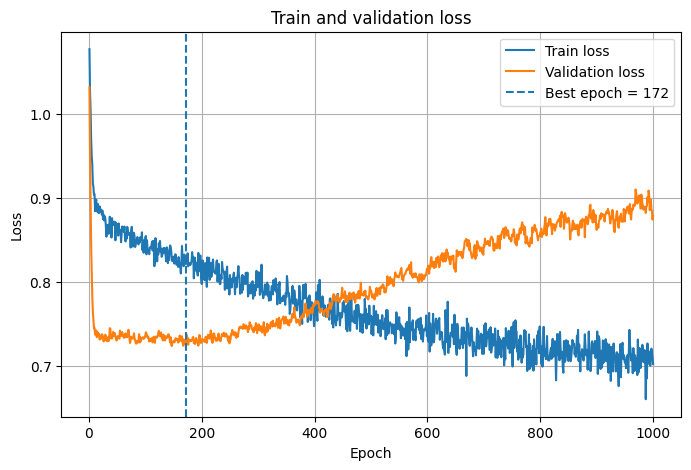

0.6486486486486487

In [4]:
run_one_experiment(model_lrelu, criterion, optimizer, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor)

In [5]:
best_num_epochs = 172

summary, results_df = run(
    model_class=MLPClassifierLeakyReLU,
    X_train_tensor=X_train_tensor,
    y_train_tensor=y_train_tensor,
    X_test_tensor=X_test_tensor,
    y_test_tensor=y_test_tensor,
    num_epochs=best_num_epochs,
)

Run 1/10
Accuracy: 0.6486 | Precision: 0.6105 | Recall: 0.5654 | Specificity: 0.7992 | F1: 0.5536

Run 2/10
Accuracy: 0.6622 | Precision: 0.5218 | Recall: 0.5586 | Specificity: 0.8099 | F1: 0.5012

Run 3/10
Accuracy: 0.6532 | Precision: 0.5645 | Recall: 0.5584 | Specificity: 0.8005 | F1: 0.5286

Run 4/10
Accuracy: 0.6802 | Precision: 0.6881 | Recall: 0.5807 | Specificity: 0.8122 | F1: 0.5544

Run 5/10
Accuracy: 0.6757 | Precision: 0.7086 | Recall: 0.5778 | Specificity: 0.8132 | F1: 0.5411

Run 6/10
Accuracy: 0.6486 | Precision: 0.5573 | Recall: 0.5553 | Specificity: 0.7990 | F1: 0.5335

Run 7/10
Accuracy: 0.6532 | Precision: 0.5603 | Recall: 0.5584 | Specificity: 0.8039 | F1: 0.5263

Run 8/10
Accuracy: 0.6396 | Precision: 0.5210 | Recall: 0.5453 | Specificity: 0.7954 | F1: 0.5109

Run 9/10
Accuracy: 0.6667 | Precision: 0.6113 | Recall: 0.5818 | Specificity: 0.8137 | F1: 0.5608

Run 10/10
Accuracy: 0.6532 | Precision: 0.5890 | Recall: 0.5541 | Specificity: 0.7994 | F1: 0.5314

Summary o

In [6]:
save_result_activation_change(
    experiment_name="Experiment_3-3_ranks_SMA_best_EMA_best_LeakyRELU",
    summary=summary
)


Saved result for Experiment_3-3_ranks_SMA_best_EMA_best_LeakyRELU
File: ../results/experiment_summary_activation_change.csv


In [7]:
import random
import numpy as np

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

input_dim = X_train_tensor.shape[1]

model_gelu = MLPClassifierGELU(input_dim=input_dim)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_gelu.parameters(),
    lr=0.001
)

Epoch 50/1000 | train loss = 0.8598 | val loss = 0.7287 | val acc = 0.6854
Epoch 100/1000 | train loss = 0.8570 | val loss = 0.7389 | val acc = 0.6685
Epoch 150/1000 | train loss = 0.8405 | val loss = 0.7294 | val acc = 0.6573
Epoch 200/1000 | train loss = 0.8223 | val loss = 0.7338 | val acc = 0.6461
Epoch 250/1000 | train loss = 0.8186 | val loss = 0.7284 | val acc = 0.6573
Epoch 300/1000 | train loss = 0.8078 | val loss = 0.7231 | val acc = 0.6404
Epoch 350/1000 | train loss = 0.7967 | val loss = 0.7279 | val acc = 0.6404
Epoch 400/1000 | train loss = 0.7798 | val loss = 0.7276 | val acc = 0.6461
Epoch 450/1000 | train loss = 0.7732 | val loss = 0.7343 | val acc = 0.6461
Epoch 500/1000 | train loss = 0.7590 | val loss = 0.7420 | val acc = 0.6348
Epoch 550/1000 | train loss = 0.7588 | val loss = 0.7542 | val acc = 0.6404
Epoch 600/1000 | train loss = 0.7639 | val loss = 0.7527 | val acc = 0.6404
Epoch 650/1000 | train loss = 0.7680 | val loss = 0.7599 | val acc = 0.6573
Epoch 700/100

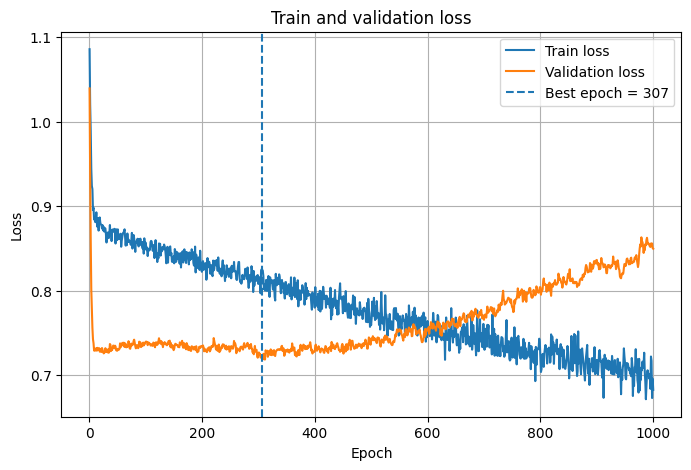

0.6351351351351351

In [8]:
run_one_experiment(model_gelu, criterion, optimizer, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor)

In [9]:
best_num_epochs = 307

summary, results_df = run(
    model_class=MLPClassifierGELU,
    X_train_tensor=X_train_tensor,
    y_train_tensor=y_train_tensor,
    X_test_tensor=X_test_tensor,
    y_test_tensor=y_test_tensor,
    num_epochs=best_num_epochs,
)

Run 1/10
Accuracy: 0.6351 | Precision: 0.5600 | Recall: 0.5582 | Specificity: 0.7978 | F1: 0.5514

Run 2/10
Accuracy: 0.6532 | Precision: 0.4281 | Recall: 0.5464 | Specificity: 0.8007 | F1: 0.4799

Run 3/10
Accuracy: 0.6757 | Precision: 0.7109 | Recall: 0.5736 | Specificity: 0.8098 | F1: 0.5406

Run 4/10
Accuracy: 0.6667 | Precision: 0.6226 | Recall: 0.5796 | Specificity: 0.8103 | F1: 0.5666

Run 5/10
Accuracy: 0.6667 | Precision: 0.7039 | Recall: 0.5675 | Specificity: 0.8056 | F1: 0.5341

Run 6/10
Accuracy: 0.6532 | Precision: 0.7629 | Recall: 0.5484 | Specificity: 0.7973 | F1: 0.4929

Run 7/10
Accuracy: 0.6441 | Precision: 0.4255 | Recall: 0.5361 | Specificity: 0.7932 | F1: 0.4744

Run 8/10
Accuracy: 0.6622 | Precision: 0.6202 | Recall: 0.5747 | Specificity: 0.8094 | F1: 0.5496

Run 9/10
Accuracy: 0.6577 | Precision: 0.6338 | Recall: 0.5574 | Specificity: 0.8015 | F1: 0.5180

Run 10/10
Accuracy: 0.6532 | Precision: 0.4294 | Recall: 0.5464 | Specificity: 0.7990 | F1: 0.4809

Summary o

In [10]:
save_result_activation_change(
    experiment_name="Experiment_3-3_ranks_SMA_best_EMA_best_GELU",
    summary=summary
)


Saved result for Experiment_3-3_ranks_SMA_best_EMA_best_GELU
File: ../results/experiment_summary_activation_change.csv
